In [1]:
using DrWatson

@quickactivate "ReservoirInverseDesign"

projectname()

"ReservoirInverseDesign"

In [2]:
using CairoMakie

In [3]:
using DifferentialEquations
using LinearAlgebra
using Random
using Statistics
using Distributed


using Distributions

using Lux
using Metal
# using LuxCUDA
using LuxCore
using NeuralOperators
using Optimisers
using Optimization
using OptimizationMultistartOptimization
using OptimizationMetaheuristics
using OptimizationBBO
using OptimizationOptimJL
using Zygote
using Enzyme
using Reactant

using JLD2


In [4]:
Threads.nthreads()

8

In [5]:
dev = reactant_device(; force=true)

(::ReactantDevice{Missing, Missing, Missing, Missing, Union{}}) (generic function with 1 method)

In [200]:
include(srcdir("kdV_Reservoir_Surrogate.jl"))
include(srcdir("experiments/Reservoir_1.jl"));
include(srcdir("plotting.jl"));

In [212]:
fno_train = false
run_bbo_comparison = false
run_surrogate_opt_MT = false

false

In [8]:
rng = Random.MersenneTwister(42);

In [131]:
# -----------------------
# generate some example solutions for a given encoding 
# -----------------------

θ = [0.05, 0.20, 0.07, 0.24, 0.433, 0.500,20]

all_u0  = []
all_solutions = []

for (n,xb) in enumerate(X_BITS)

    u01 = encode_initial_condition_7(xb, x, θ, p_soliton)

    prob_01 = ODEProblem(kdv_fd!, u01, (0.0, t_end), p_reservoir)

    sol = solve(prob_01, AutoVern7(RadauIIA5()));

    push!(all_u0,u01)
    push!(all_solutions,sol.u[end])
end


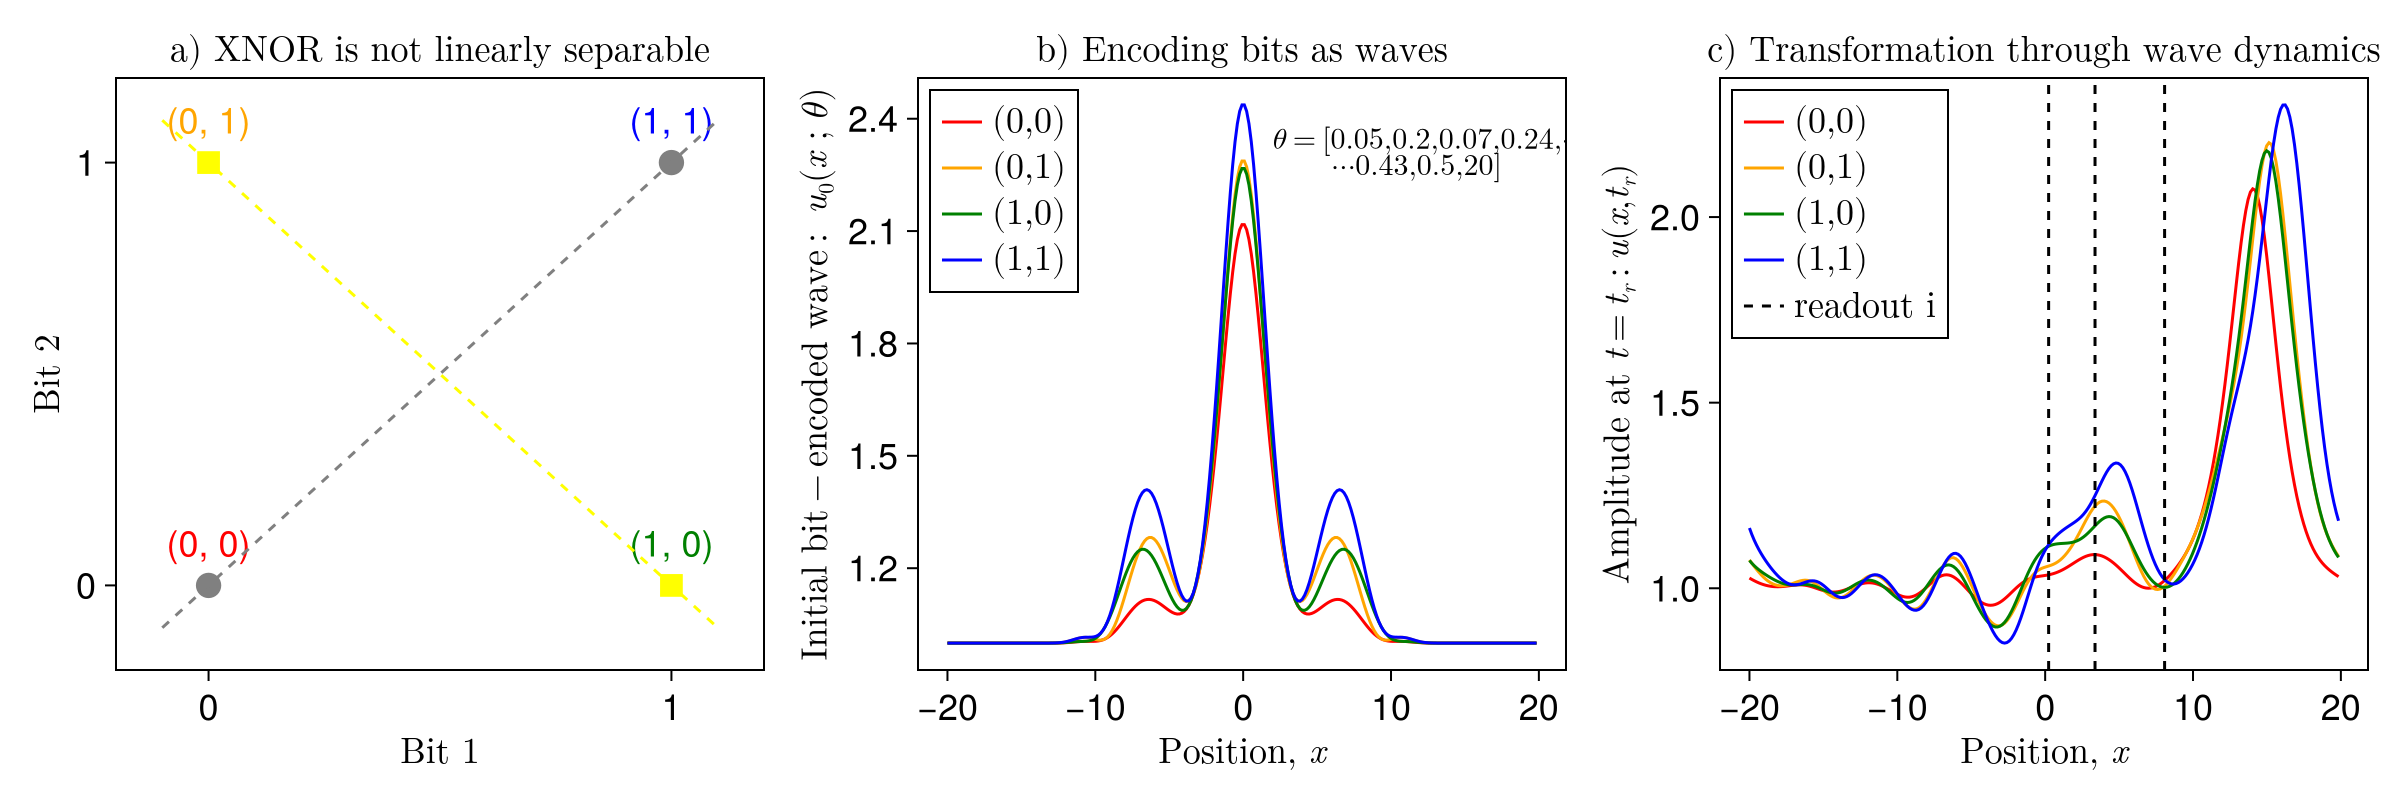

In [182]:
# -----------------------
# Plot solutions
# -----------------------
include(srcdir("plotting.jl"));

fig = CairoMakie.Figure(size = (1200,400),fontsize = 18.)

ax1 = Axis(fig[1,1],title = L"\text{a) XNOR is not linearly separable}",xlabel = L"\text{Bit 1}",ylabel = L"\text{Bit 2}",xticks = ([0,1], ["0","1"]),yticks = ([0,1], ["0","1"]),limits = (-0.2, 1.2, -0.2, 1.2),xgridvisible = false,ygridvisible = false)
ax2 = Axis(fig[1,2], xlabel = L"\text{Position, } x", ylabel = L"\text{Initial bit-encoded wave: } u_0(x \text{ ; }  \theta)",xgridvisible = false,ygridvisible = false,title = L"\text{b) Encoding bits as waves}")
ax3 = Axis(fig[1,3], xlabel = L"\text{Position, } x", ylabel = L"\text{Amplitude at } t = t_r {: } u(x, t_r)",xgridvisible = false,ygridvisible = false,title = L"\text{c) Transformation through wave dynamics}")


plot_XNOR!(ax1)

colors = [:red,:orange,:green,:blue]
labels = [L"(0,0)",L"(0,1)",L"(1,0)",L"(1,1)"]

x_index_readout_positions = [130,150,180]

for n in 1:4
    lines!(ax2,x,all_u0[n],color = colors[n], label = labels[n])
    lines!(ax3,x,all_solutions[n],color = colors[n], label = labels[n])
end

for (n,r) in enumerate(x_index_readout_positions)
    if n == 1
        vlines!(ax3,x[r],linestyle = :dash,color = :black,label = L"\text{readout i}")
    else
        vlines!(ax3,x[r],linestyle = :dash,color = :black)
    end
end

axislegend(ax2,position = :lt)
axislegend(ax3,position = :lt)

text!(ax2,L"\theta = [0.05, 0.2, 0.07, 0.24, \cdots",position = (2,2.3),fontsize = 15.)
text!(ax2,L" \cdots 0.43, 0.5,20]",position = (6,2.23),fontsize = 15.)

save(plotsdir("ExampleEncoding.pdf"),fig)

fig

In [10]:
# -----------------------
# load training data
# -----------------------

data = load(datadir("exp_raw/kdV/kdV_train_500_100.jld2"))

X_train = data["X_train"]
Y_train = data["Y_train"]

X_test = data["X_test"]
Y_test = data["Y_test"]

meta_train = data["meta_train"]
meta_test = data["meta_test"];

Loading FNO...


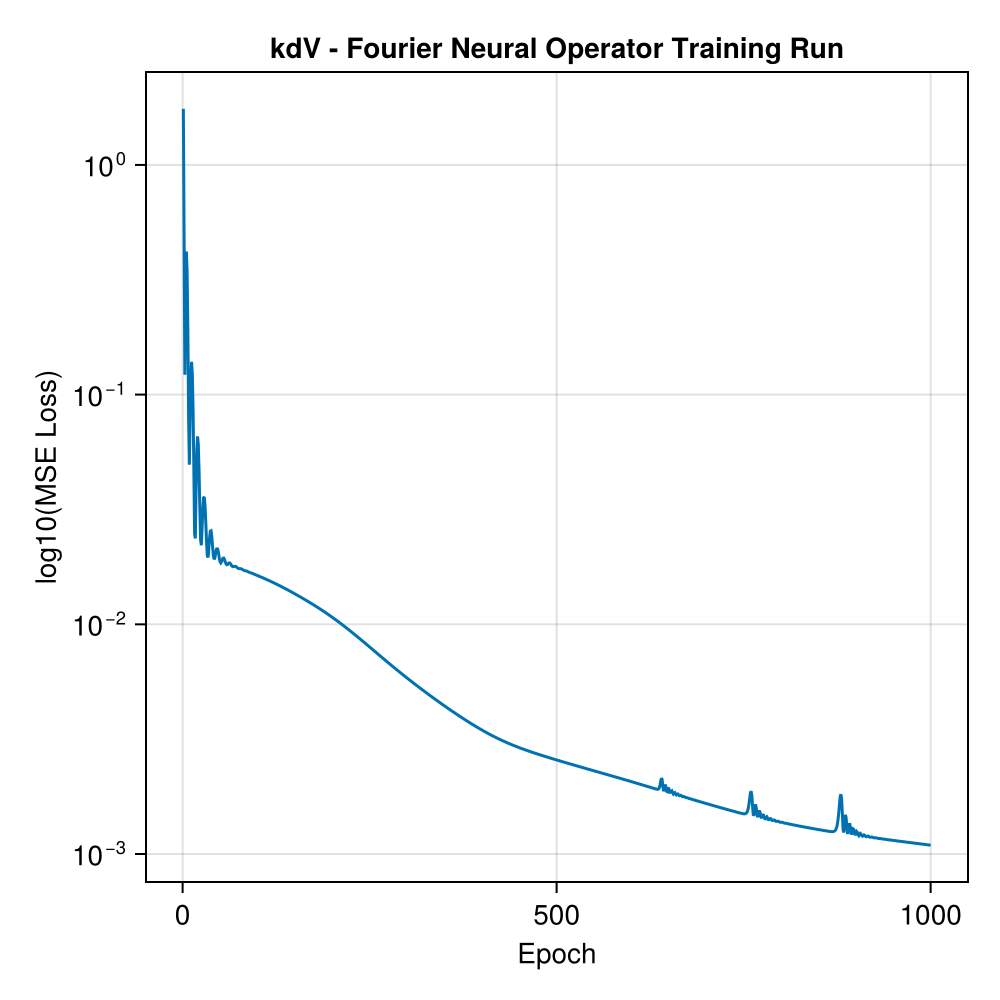

In [186]:
 if fno_train

    # ------------------------
    # Train FNO surrogate
    # ------------------------

    println("Training FNO...")

    fno_width = 32
    fno_modes = 16
    training_epochs = 1000

    fno, ps, st, losses = train_fno(
        X_train,
        Y_train;
        width = fno_width,
        modes = fno_modes,
        epochs = training_epochs ,
        lr = 3f-3,
        rng = rng,
        xdev = dev,
    )

    println("Final training loss = ", losses[end])

    ps_cpu = ps |> cpu_device()
    st_cpu = st |> cpu_device()

    fno_data_dict = Dict()
    fno_data_dict["width"] = fno_width
    fno_data_dict["modes"] = fno_modes
    fno_data_dict["ps"] = ps_cpu
    fno_data_dict["st"] = st_cpu
    fno_data_dict["losses"] = losses

    save(datadir("exp_raw","fno_trained_TD500_TE100_Epochs" * string(training_epochs) * ".jld2"),fno_data_dict)

 else

    println("Loading FNO...")

    fno_model = load(datadir("exp_raw","fno_trained_TD500_TE100_Epochs1000.jld2"))

    fno_width = fno_model["width"]
    fno_modes = fno_model["modes"]

    fno = FourierNeuralOperator(
        gelu;
        chs = (1, fno_width, fno_width, 2fno_width, 1),
        modes = (fno_modes,),
    )

    ps_cpu = fno_model["ps"]
    st_cpu = fno_model["st"]
    losses = fno_model["losses"]
 end

 fig = CairoMakie.Figure(size = (500,500))
 ax = Axis(fig[1,1],xlabel = "Epoch",ylabel = "log10(MSE Loss)", yscale = log10,title = "kdV - Fourier Neural Operator Training Run")
 
 lines!(ax,losses)
 
 fig

In [198]:
# ------------------------
# Inverse design, surrogate model
#
# ------------------------

n_readouts = 4

θ0 = [rand(Uniform(lb,ub)) for (lb,ub) in zip(lb_theta,ub_theta)]

xreadout0 = collect(range(-8.0, 8.0, length=n_readouts))

println("Optimizing theta + readout positions...")

sol = optimize_theta_and_readouts(
    fno,
    ps_cpu,
    st_cpu,
    θ0,
    xreadout0,
    lb_theta,
    ub_theta,
    x,
    p_soliton;
    λ_rep = 1f-3,
    sigma = 1.5 * dx,
    nstarts = 100,
)

zbest = Array(sol.u)
θ_best = zbest[1:7]
xread_best = zbest[8:end]

println("θ_best = ", θ_best)
println("xread_best = ", xread_best)

Optimizing theta + readout positions...


θ_best = 

[0.00999999977651161, 0.34999999403951004, 0.00999999977651756, 0.34999999403950904, 0.633503932656499, 0.20741244885333995, 15.257729402156235]
xread_best = [17.460379343676053, 3.6363664786217225, 15.841842348831305, -0.1264507568872367]


In [199]:
# ------------------------
# Surrogate score
# ------------------------

R_hat = surrogate_readout_matrix(
    fno, ps_cpu, st_cpu, θ_best, xread_best, x, p_soliton;
    sigma = 1.5 * dx,
)
println("Surrogate R = ")
display(R_hat)
println("Surrogate separability score = ", separability_score(R_hat))

# ------------------------
# Ground-truth PDE validation
# ------------------------

println("Validating on the full PDE...")

R_true = true_readout_matrix(
    θ_best,
    xread_best,
    x,
    prob,
    t_end,
    p_soliton;
    sigma = 1.5 * dx,
    reltol = 1e-10,
    abstol = 1e-10,
)

println("True R = ")
display(R_true)
println("True separability score = ", separability_score(R_true))

if size(R_true, 1) == size(R_true, 2)
    surrogate_best_fitness = abs(det(R_true))
    println("True |det(R)| = ", surrogate_best_fitness)
else
    surrogate_best_fitness = det(R_true * R_true')
    println("True det(RR') = ", surrogate_best_fitness)
end

4×4 Matrix{Float64}:
 0.98118  0.98886  1.2646   1.01241
 1.87764  1.01426  2.47048  1.00101
 1.56479  1.22498  2.24243  0.869346
 2.9781   1.223    1.69332  0.837594

Surrogate R = 
Surrogate separability score = -0.2536553552697475
Validating on the full PDE...
True R = 

4×4 Matrix{Float64}:
 1.07343  1.00575  1.31877  0.998081
 1.7556   1.01678  2.56123  0.977205
 1.50721  1.25407  2.22771  0.855802
 2.89239  1.16535  1.5695   0.938314


True separability score = -0.23525606785702835
True |det(R)| = 0.7903674357623931


In [226]:
run_surrogate_opt_MT = true

if run_surrogate_opt_MT
    n_trials = 5
    gradient_alg_summary_data = pmap(worker -> evaluate_gradient_surrogate_opt(fno,ps_cpu,st_cpu,lb_theta,ub_theta,x,p_soliton,dx,100),1:n_trials)
    save(datadir("exp_raw/kdV_TestSurrogate_500_MT_20.jld2"),Dict("alg_summary" => gradient_alg_summary_data))
else
    gradient_alg_summary_data = load(datadir("exp_raw/kdV_TestSurrogate_500_MT_20.jld2"))["alg_summary"]
end

nothing ;

In [217]:
if run_bbo_comparison

    n_fno_training_samples = Int(size(X_train,3) / 4)

    alg_names = ["Adaptive_Differential_Evolution","Exponential_NES"]
    alg_methods = [BBO_adaptive_de_rand_1_bin_radiuslimited(),BBO_xnes(),BBO_generating_set_search()]

    bbo_alg_summary_data = []

    for (alg_name,alg) in zip(alg_names,alg_methods)

        println("Optimizing theta + readout positions for " * alg_name * "...")

        meta_alg = false

        sol_opt = optimize_theta_and_readouts_BBO(
            prob,
            t_end,
            θ0,
            xreadout0,
            lb_theta,
            ub_theta,
            x,
            p_soliton;
            MaxFuncEvals = n_fno_training_samples,
            λ_rep = 1f-3,
            sigma = 1.5 * dx,
            alg = alg,
            meta_alg = meta_alg)

        zbest = Array(sol_opt.u)
        θ_best = zbest[1:7]
        xread_best = zbest[8:end]

        R_true = true_readout_matrix(
                        θ_best,
                        xread_best,
                        x,
                        prob,
                        t_end,
                        p_soliton;
                        sigma = 1.5 * dx)

        
        println("separability score = ", separability_score(R_true))

        if size(R_true, 1) == size(R_true, 2)
            fitness = abs(det(R_true))
            println("True |det(R)| = ", fitness)
        else
            fitness = det(R_true * R_true')
            println("True det(RR') = ", fitness)
        end

        push!(bbo_alg_summary_data,[(θ_best,xread_bestfitness)])

    end
else
    bbo_alg_summary_data = load(datadir("exp_raw/kdV_TestBBO_2Alg_500_MT_100.jld2"))["alg_summary"]
end

nothing ;

In [221]:
alg1_bbo_best_seperability = map(x->x[3],bbo_alg_summary_data[1])
alg2_bbo_best_seperability = map(x->x[3],bbo_alg_summary_data[2]);

gradient_surrogate_best_seperability = map(x->x[3],gradient_alg_summary_data);

BoundsError: BoundsError: attempt to access Float64 at index [3]

In [46]:
alg_comparison_det = reduce(vcat,[gradient_surrogate_best_seperability,alg2_bbo_best_seperability,alg1_bbo_best_seperability])
alg_comparison_class = reduce(vcat,[[n for _ in 1:size(v)] for (n,v) in enumerate([gradient_surrogate_best_seperability,alg2_bbo_best_seperability,alg1_bbo_best_seperability]))

alg_comparison_names = vcat(["Surrogate + LBFGS"],alg_names)

fig = CairoMakie.Figure(size = (500,500))

ax = Axis(fig[1,1],xlabel = "Search algorithm",ylabel = "True |det(R)|",title = "kdV RID: search comparison w/ 2500 function evals")

boxplot!(ax,alg_comparison_class,alg_comparison_det)

ax.xticks = (1:3,alg_comparison_names)
ax.xticklabelrotation = 45.

fig